### Pacotes importados

In [50]:
# codigo aqui

## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

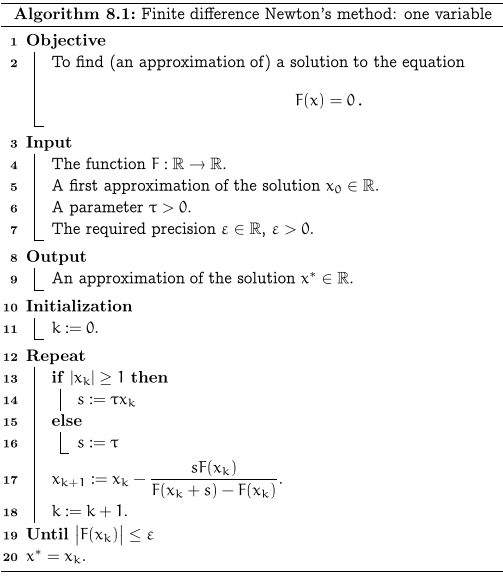

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$

k 	 xk 			 F(xk) 			 s
0 	 +2.00000000E+00 	 +2.00000000E+00 	 ---
1 	 +1.50000003E+00 	 +2.50000076E-01 	 +2.00000000E-07
2 	 +1.41666667E+00 	 +6.94446024E-03 	 +1.50000003E-07
3 	 +1.41421569E+00 	 +6.00768246E-06 	 +1.41666667E-07
4 	 +1.41421356E+00 	 +4.81081841E-12 	 +1.41421569E-07
5 	 +1.41421356E+00 	 +4.44089210E-16 	 +1.41421356E-07

x* = 1.4142135623730951


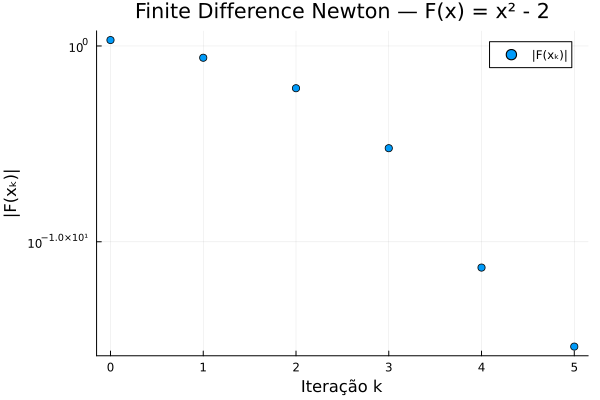

In [51]:
# Algoritmo 8.1 - Finite Difference Newton's Method (uma variável)
# F(x) = x² - 2, x₀ = 2, τ = 1e-7, ε = 1e-15

using Printf
using Plots

# Função
F(x) = x^2 - 2.0

# Parâmetros
x = 2.0
τ = 1e-7
ε = 1e-15
k = 0

# Armazenar iterações para o gráfico
ks = Int[]
Fxs = Float64[]

# Cabeçalho
println("k \t xk \t\t\t F(xk) \t\t\t s")

push!(ks, k)
push!(Fxs, abs(F(x)))
@printf("%d \t %+.8E \t %+.8E \t ---\n", k, x, F(x))

# Loop principal
while abs(F(x)) >= ε

    # Escolha do passo s (diferença finita)
    s = abs(x) >= 1.0 ? τ * x : τ

    # Atualização de Newton por diferença finita
    x = x - s * F(x) / (F(x + s) - F(x))
    k += 1

    push!(ks, k)
    push!(Fxs, abs(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), s)
end

println("\nx* = ", x)

# Gráfico
plot(ks, Fxs,
    seriestype = :scatter,
    xlabel = "Iteração k",
    ylabel = "|F(xₖ)|",
    title = "Finite Difference Newton — F(x) = x² - 2",
    label = "|F(xₖ)|",
    marker = :circle,
    yscale = :log10,
    yformatter = :scientific,
    legend = :topright
)

Run the example with $x_0=2$ and $\tau=0.1$

k 	 xk 			 F(xk) 			 s
0 	 +2.00000000E+00 	 +2.00000000E+00 	 ---
1 	 +1.52380952E+00 	 +3.21995465E-01 	 +2.00000000E-01
2 	 +1.42318594E+00 	 +2.54582228E-02 	 +1.52380952E-01
3 	 +1.41466775E+00 	 +1.28485582E-03 	 +1.42318594E-01
4 	 +1.41423526E+00 	 +6.13706622E-05 	 +1.41466775E-01
5 	 +1.41421460E+00 	 +2.92283950E-06 	 +1.41423526E-01
6 	 +1.41421361E+00 	 +1.39183802E-07 	 +1.41421460E-01
7 	 +1.41421356E+00 	 +6.62780186E-09 	 +1.41421361E-01
8 	 +1.41421356E+00 	 +3.15609761E-10 	 +1.41421356E-01
9 	 +1.41421356E+00 	 +1.50284230E-11 	 +1.41421356E-01
10 	 +1.41421356E+00 	 +7.15427717E-13 	 +1.41421356E-01
11 	 +1.41421356E+00 	 +3.41948692E-14 	 +1.41421356E-01
12 	 +1.41421356E+00 	 +1.33226763E-15 	 +1.41421356E-01
13 	 +1.41421356E+00 	 +4.44089210E-16 	 +1.41421356E-01

x* = 1.4142135623730951


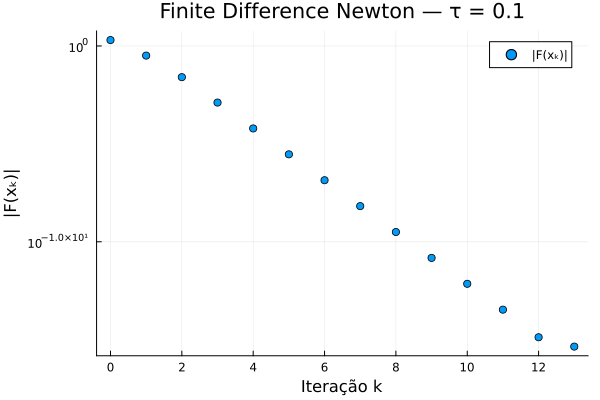

In [52]:
# Algoritmo 8.1 - Finite Difference Newton's Method (uma variável)
# F(x) = x² - 2, x₀ = 2, τ = 0.1, ε = 1e-15

using Printf
using Plots

# Função
F(x) = x^2 - 2.0

# Parâmetros
x   = 2.0
τ   = 0.1      # <-- único valor alterado
ε   = 1e-15
k   = 0

ks  = Int[]
Fxs = Float64[]

println("k \t xk \t\t\t F(xk) \t\t\t s")

push!(ks, k)
push!(Fxs, abs(F(x)))
@printf("%d \t %+.8E \t %+.8E \t ---\n", k, x, F(x))

while abs(F(x)) >= ε

    s = abs(x) >= 1.0 ? τ * x : τ

    x = x - s * F(x) / (F(x + s) - F(x))
    k += 1

    push!(ks, k)
    push!(Fxs, abs(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), s)
end

println("\nx* = ", x)

plot(ks, Fxs,
    seriestype = :scatter,
    xlabel     = "Iteração k",
    ylabel     = "|F(xₖ)|",
    title      = "Finite Difference Newton — τ = 0.1",
    label      = "|F(xₖ)|",
    marker     = :circle,
    yscale     = :log10,
    yformatter = :scientific,
    legend     = :topright
)

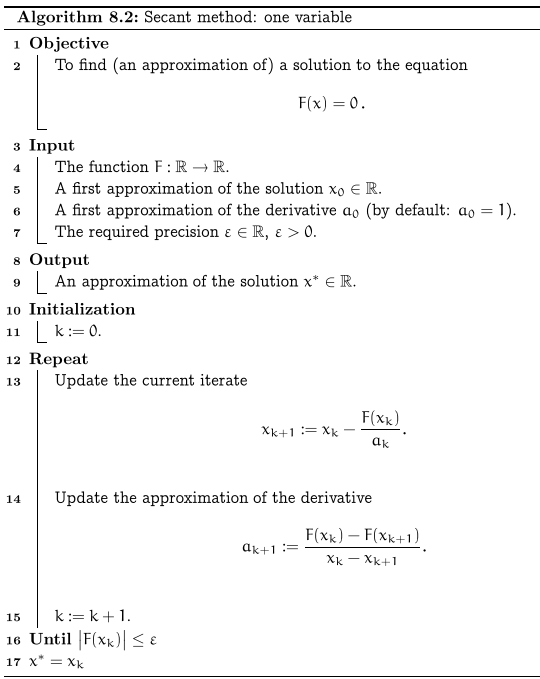

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$

k 	 xk 			 F(xk) 			 ak
0 	 +2.00000000E+00 	 +2.00000000E+00 	 +1.00000000E+00
1 	 +0.00000000E+00 	 -2.00000000E+00 	 +2.00000000E+00
2 	 +1.00000000E+00 	 -1.00000000E+00 	 +1.00000000E+00
3 	 +2.00000000E+00 	 +2.00000000E+00 	 +3.00000000E+00
4 	 +1.33333333E+00 	 -2.22222222E-01 	 +3.33333333E+00
5 	 +1.40000000E+00 	 -4.00000000E-02 	 +2.73333333E+00
6 	 +1.41463415E+00 	 +1.18976800E-03 	 +2.81463415E+00
7 	 +1.41421144E+00 	 -6.00728684E-06 	 +2.82884558E+00
8 	 +1.41421356E+00 	 -8.93145558E-10 	 +2.82842500E+00
9 	 +1.41421356E+00 	 +8.88178420E-16 	 +2.82842706E+00

x* = 1.4142135623730954


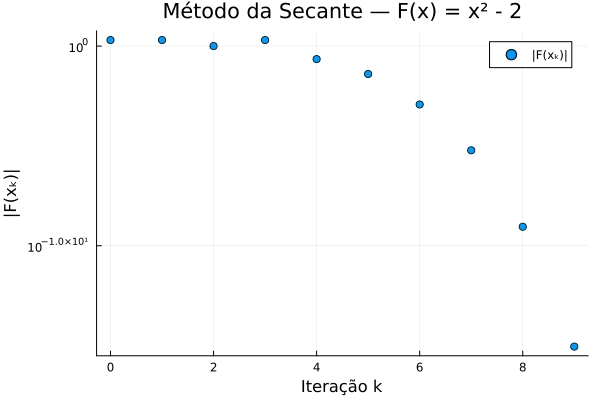

In [53]:
# Algoritmo 8.2 - Método da Secante (uma variável)
# F(x) = x² - 2, x₀ = 2, a₀ = 1, ε = 1e-15

using Printf
using Plots

# Função
F(x) = x^2 - 2.0

# Parâmetros
x  = 2.0
a  = 1.0     # aproximação inicial da derivada
ε  = 1e-15
k  = 0

ks  = Int[]
Fxs = Float64[]

println("k \t xk \t\t\t F(xk) \t\t\t ak")

push!(ks, k)
push!(Fxs, abs(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), a)

while abs(F(x)) >= ε

    # Passo 1: atualizar o iterado
    x_new = x - F(x) / a

    # Passo 2: atualizar a aproximação da derivada (fórmula da secante)
    a = (F(x) - F(x_new)) / (x - x_new)

    # Avançar
    x = x_new
    k += 1

    push!(ks, k)
    push!(Fxs, abs(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x, F(x), a)
end

println("\nx* = ", x)

plot(ks, Fxs,
    seriestype = :scatter,
    xlabel     = "Iteração k",
    ylabel     = "|F(xₖ)|",
    title      = "Método da Secante — F(x) = x² - 2",
    label      = "|F(xₖ)|",
    marker     = :circle,
    yscale     = :log10,
    yformatter = :scientific,
    legend     = :topright
)

### Algorithm 8.3: finite difference Newton's method: $n$ variables

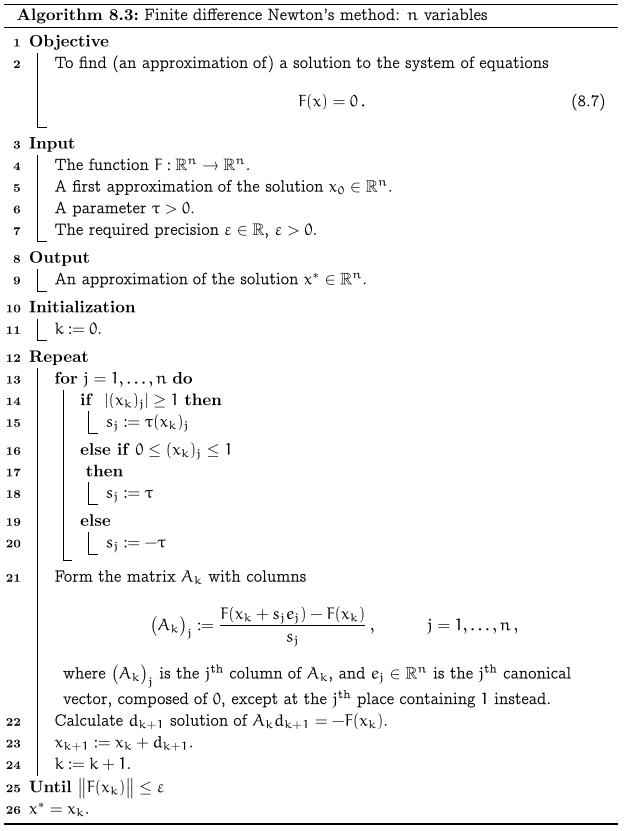

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$

k 	 x1 			 x2 			 ||F(xk)||
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +3.45723769E+00
1 	 +1.52359228E-01 	 +1.19528158E+00 	 +1.15470878E+00
2 	 -1.08376850E-02 	 +1.03611119E+00 	 +1.14042632E-01
3 	 -8.89667833E-04 	 +1.00153532E+00 	 +3.94234561E-03
4 	 -1.37016930E-06 	 +1.00000294E+00 	 +8.08061365E-06
5 	 -5.68811577E-12 	 +1.00000000E+00 	 +2.98639245E-11
6 	 -1.10724444E-16 	 +1.00000000E+00 	 +4.44089210E-16

x* = [-1.1072444444653868e-16, 1.0000000000000002]


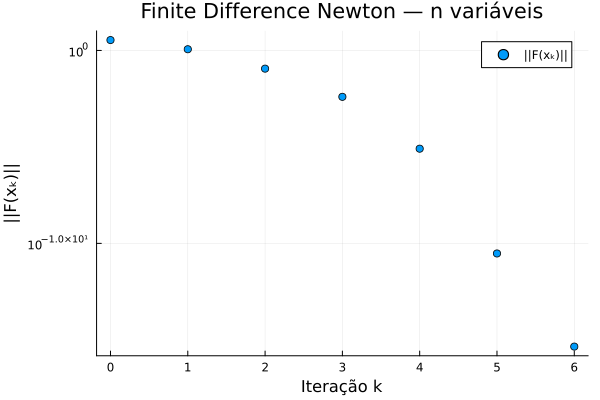

In [54]:
# Algoritmo 8.3 - Finite Difference Newton's Method (n variáveis)
# F(x) = [(x1+1)² + x2² - 2 ; exp(x1) + x2³ - 2]
# x₀ = [1, 1], τ = 1e-7, ε = 1e-15

using Printf
using LinearAlgebra
using Plots

# Função vetorial
function F(x)
    return [
        (x[1] + 1)^2 + x[2]^2 - 2.0,
        exp(x[1]) + x[2]^3 - 2.0
    ]
end

# Parâmetros
x  = [1.0, 1.0]
τ  = 1e-7
ε  = 1e-15
k  = 0
n  = length(x)

ks    = Int[]
norms = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

while norm(F(x)) >= ε

    Fx = F(x)

    # Passo 1: calcular passo sⱼ para cada componente j
    s = zeros(n)
    for j in 1:n
        if abs(x[j]) >= 1.0
            s[j] = τ * x[j]
        elseif 0.0 <= x[j] < 1.0
            s[j] = τ
        else
            s[j] = -τ
        end
    end

    # Passo 2: montar a matriz Jacobiana aproximada Ak
    # Cada coluna j = [F(x + sⱼeⱼ) - F(x)] / sⱼ
    Ak = zeros(n, n)
    for j in 1:n
        ej      = zeros(n)
        ej[j]   = 1.0
        Ak[:, j] = (F(x + s[j] * ej) - Fx) / s[j]
    end

    # Passo 3: resolver Ak * d = -F(x)
    d = Ak \ (-Fx)

    # Passo 4: atualizar iterado
    x = x + d
    k += 1

    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

println("\nx* = [", x[1], ", ", x[2], "]")

plot(ks, norms,
    seriestype = :scatter,
    xlabel     = "Iteração k",
    ylabel     = "||F(xₖ)||",
    title      = "Finite Difference Newton — n variáveis",
    label      = "||F(xₖ)||",
    marker     = :circle,
    yscale     = :log10,
    yformatter = :scientific,
    legend     = :topright
)

Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$

k 	 x1 			 x2 			 ||F(xk)||
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +3.45723769E+00
1 	 +1.64629659E-01 	 +1.20238971E+00 	 +1.21852778E+00
2 	 -1.45741083E-02 	 +1.05713499E+00 	 +1.88972898E-01
3 	 -5.72356301E-03 	 +1.00976678E+00 	 +2.52536228E-02
4 	 -4.76896360E-04 	 +1.00122016E+00 	 +3.51842725E-03
5 	 -6.65078241E-05 	 +1.00014167E+00 	 +3.88814236E-04
6 	 -7.02284568E-06 	 +1.00001628E+00 	 +4.57231912E-05
7 	 -8.38649630E-07 	 +1.00000187E+00 	 +5.19256314E-06
8 	 -9.45112631E-08 	 +1.00000021E+00 	 +5.98865000E-07
9 	 -1.09384631E-08 	 +1.00000002E+00 	 +6.85703825E-08
10 	 -1.25042236E-09 	 +1.00000000E+00 	 +7.87759101E-09
11 	 -1.43761226E-10 	 +1.00000000E+00 	 +9.03605360E-10
12 	 -1.64844702E-11 	 +1.00000000E+00 	 +1.03723090E-10
13 	 -1.89262915E-12 	 +1.00000000E+00 	 +1.19022729E-11
14 	 -2.17295867E-13 	 +1.00000000E+00 	 +1.36591792E-12
15 	 -2.50573672E-14 	 +1.00000000E+00 	 +1.56335171E-13
16 	 -2.81453698E-15 	 +1.00000000E+00 	 +1.79018084E-14
17 	 -2.53868

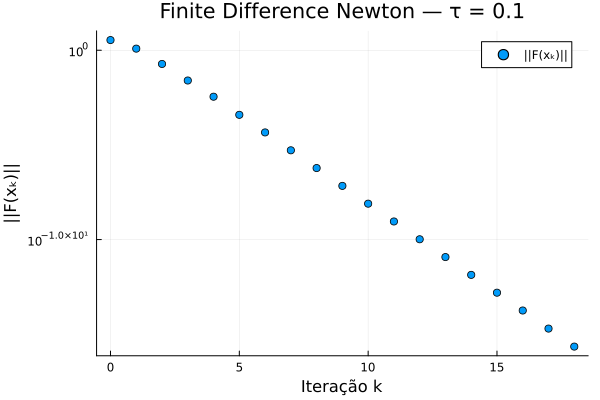

In [55]:
# Algoritmo 8.3 - Finite Difference Newton's Method (n variáveis)
# F(x) = [(x1+1)² + x2² - 2 ; exp(x1) + x2³ - 2]
# x₀ = [1, 1], τ = 0.1, ε = 1e-15

using Printf
using LinearAlgebra
using Plots

function F(x)
    return [
        (x[1] + 1)^2 + x[2]^2 - 2.0,
        exp(x[1]) + x[2]^3 - 2.0
    ]
end

# Parâmetros
x  = [1.0, 1.0]
τ  = 0.1       # <-- único valor alterado
ε  = 1e-15
k  = 0
n  = length(x)

ks    = Int[]
norms = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")

push!(ks, k)
push!(norms, norm(F(x)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))

while norm(F(x)) >= ε

    Fx = F(x)

    s = zeros(n)
    for j in 1:n
        if abs(x[j]) >= 1.0
            s[j] = τ * x[j]
        elseif 0.0 <= x[j] < 1.0
            s[j] = τ
        else
            s[j] = -τ
        end
    end

    Ak = zeros(n, n)
    for j in 1:n
        ej       = zeros(n)
        ej[j]    = 1.0
        Ak[:, j] = (F(x + s[j] * ej) - Fx) / s[j]
    end

    d = Ak \ (-Fx)
    x = x + d
    k += 1

    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

println("\nx* = [", x[1], ", ", x[2], "]")

plot(ks, norms,
    seriestype = :scatter,
    xlabel     = "Iteração k",
    ylabel     = "||F(xₖ)||",
    title      = "Finite Difference Newton — τ = 0.1",
    label      = "||F(xₖ)||",
    marker     = :circle,
    yscale     = :log10,
    yformatter = :scientific,
    legend     = :topright
)

### Algorithm 8.4: secant method: $n$ variables

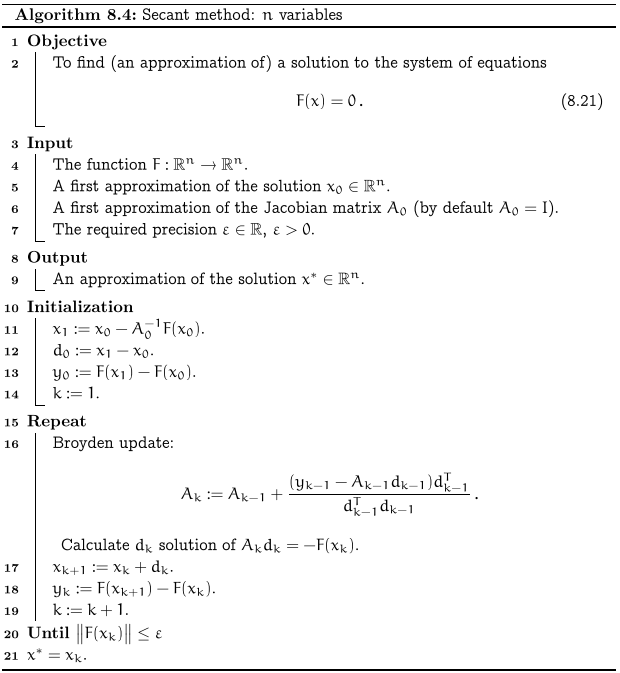

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$


k 	 x1 			 x2 			 ||F(xk)||
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +3.45723769E+00
1 	 -2.00000000E+00 	 -7.18281828E-01 	 +2.28706232E+00
2 	 -1.66450026E+00 	 +8.30921596E-01 	 +1.51117837E+00
3 	 -2.42562564E-01 	 +2.03771214E+00 	 +7.74156513E+00
4 	 -1.24155582E+00 	 +7.71291329E-01 	 +1.83898030E+00
5 	 -5.80521668E-01 	 +4.22211781E-01 	 +2.13825933E+00
6 	 -3.26193209E+00 	 +2.03825960E+00 	 +9.75687582E+00
7 	 -1.10905274E+00 	 +7.07509612E-01 	 +1.98608842E+00
8 	 -1.47906232E+00 	 +9.31390079E-01 	 +1.32101192E+00
9 	 -1.83287024E+00 	 +1.27828329E+00 	 +4.11358887E-01
10 	 -1.70715660E+00 	 +1.19091935E+00 	 +1.53129989E-01
11 	 -1.70952786E+00 	 +1.21458043E+00 	 +3.46604640E-02
12 	 -1.71400159E+00 	 +1.22173904E+00 	 +4.49128919E-03
13 	 -1.71377557E+00 	 +1.22091912E+00 	 +1.83309066E-04
14 	 -1.71374534E+00 	 +1.22088402E+00 	 +1.56208638E-05
15 	 -1.71374739E+00 	 +1.22088679E+00 	 +1.85422885E-07
16 	 -1.71374741E+00 	 +1.22088682E+00 	 +3.89249065E-10
17 	 -1.71374

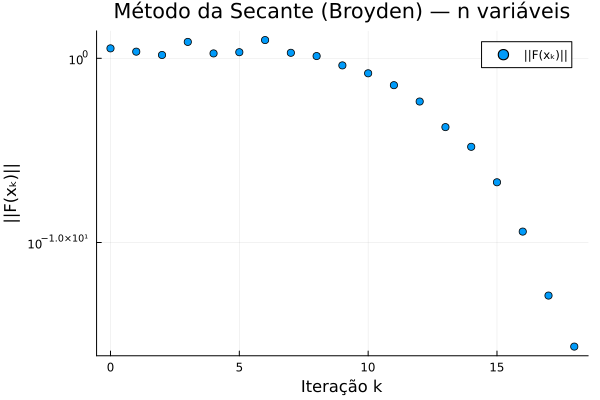

In [56]:
# Algoritmo 8.4 - Método da Secante (n variáveis) — Atualização de Broyden
# F(x) = [(x1+1)² + x2² - 2 ; exp(x1) + x2³ - 2]
# x₀ = [1, 1], A₀ = I, ε = 1e-15

using Printf
using LinearAlgebra
using Plots

# Função vetorial
function F(x)
    return [
        (x[1] + 1)^2 + x[2]^2 - 2.0,
        exp(x[1]) + x[2]^3 - 2.0
    ]
end

# Parâmetros
x0 = [1.0, 1.0]
ε  = 1e-15
n  = length(x0)
A  = Matrix{Float64}(I, n, n)   # A₀ = I (identidade)

# Inicialização (linhas 11-14 do algoritmo)
x1 = x0 - A \ F(x0)            # x₁ := x₀ - A₀⁻¹ F(x₀)
d  = x1 - x0                   # d₀ := x₁ - x₀
y  = F(x1) - F(x0)             # y₀ := F(x₁) - F(x₀)
x  = x1
k  = 1

ks    = Int[]
norms = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||F(xk)||")
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", 0, x0[1], x0[2], norm(F(x0)))
@printf("%d \t %+.8E \t %+.8E \t %+.8E\n", 1, x[1],  x[2],  norm(F(x)))

push!(ks, 0); push!(norms, norm(F(x0)))
push!(ks, 1); push!(norms, norm(F(x)))

# Loop principal — Repeat (linha 15)
while norm(F(x)) >= ε

    # Atualização de Broyden: Ak := Ak-1 + (y - A·d)·dᵀ / (dᵀ·d)
    A = A + ((y - A * d) * d') / (d' * d)

    # Resolver Ak * dk = -F(xk)
    dk = A \ (-F(x))

    # Atualizar iterado
    x_new = x + dk

    # Atualizar y e d para próxima iteração
    y = F(x_new) - F(x)
    d = dk

    x = x_new
    k += 1

    push!(ks, k)
    push!(norms, norm(F(x)))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, x[1], x[2], norm(F(x)))
end

println("\nx* = [", x[1], ", ", x[2], "]")

plot(ks, norms,
    seriestype = :scatter,
    xlabel     = "Iteração k",
    ylabel     = "||F(xₖ)||",
    title      = "Método da Secante (Broyden) — n variáveis",
    label      = "||F(xₖ)||",
    marker     = :circle,
    yscale     = :log10,
    yformatter = :scientific,
    legend     = :topright
)